# Delivery Time Prediction

## Objective
The goal of this notebook is to build a machine learning model capable of predicting delivery time in minutes based on order and delivery-related features.

## Main steps

In this notebook, I:

1. import the required libraries  
2. load and explore the dataset  
3. analyze and handle missing values  
4. perform exploratory data analysis (EDA)  
5. build a preprocessing pipeline (imputation + encoding)  
6. split the data into training and testing sets  
7. train and compare multiple regression models  
8. evaluate models using cross-validation and test metrics (MAE, RMSE, R²)  
9. tune the best model using GridSearchCV  
10. analyze residuals to assess model behavior  
11. interpret the final model  
12. save the trained pipeline for deployment  

## 1. Importing libraries

This section imports the Python libraries used for data manipulation, visualization, model training, evaluation, and model saving.

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

import joblib

## 2. Loading the dataset

The dataset is loaded from a CSV file.  
We display the first rows to understand its structure.

In [214]:
df = pd.read_csv("data/dataset.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 3. Data exploration

Before building a model, it is important to understand the structure and quality of the dataset.

We use:
- `info()` to inspect data types and detect missing values
- `describe()` to analyze statistical properties such as mean, standard deviation, and range

This step helps identify potential issues such as:
- incorrect data types
- missing values
- extreme values that could affect the model

In [215]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## 4. Missing values analysis

We check the number of missing values in each column.

This step is important because missing data can:
- reduce model performance
- introduce bias if not handled properly

In this dataset, about 30 values are missing in several columns (Weather, Traffic_Level, Time_of_Day, Courier_Experience_yrs).

We then inspect the rows containing missing values to understand if they follow a pattern.

In [216]:
missing = df.isnull().sum()
print(missing)

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [217]:
df[df.isnull().any(axis=1)].head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
14,939,2.80,Clear,High,Morning,Scooter,10,NaN,33
24,211,11.20,Clear,Medium,Morning,Bike,23,NaN,73
42,313,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,494,4.17,NaN,Low,Evening,Scooter,5,1.0,22


## 5. Handling missing values

Before removing missing values, we inspect the affected rows.

Since missing values appear relatively limited compared to the dataset size and do not follow a clear pattern, we choose to remove them using `dropna()`.

This is a simple approach that avoids introducing artificial values, although it slightly reduces the dataset size.

In [218]:
df = df.dropna()

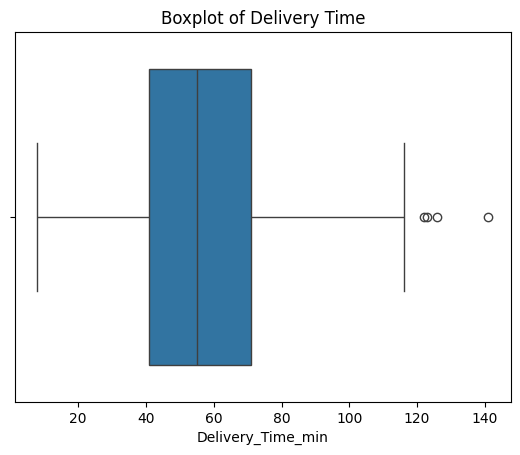

In [219]:
plt.figure()
sns.boxplot(x=df["Delivery_Time_min"])
plt.title("Boxplot of Delivery Time")
plt.show()

### Interpretation

The boxplot shows that delivery time has several outliers, with values reaching up to around 150 minutes.

This indicates that some deliveries take significantly longer than average.  
These outliers may correspond to difficult delivery conditions such as long distances or heavy traffic.

Since these values appear realistic, they are kept in the dataset.




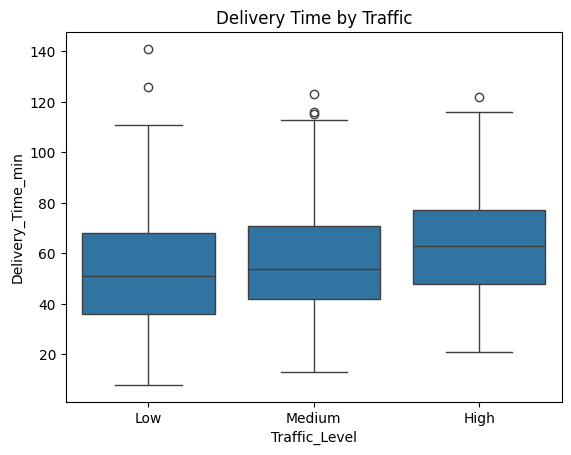

In [220]:
plt.figure()
sns.boxplot(x=df["Traffic_Level"], y=df["Delivery_Time_min"])
plt.title("Delivery Time by Traffic")
plt.show()

### Interpretation

Delivery time varies depending on traffic conditions.

Higher traffic levels tend to be associated with longer delivery times, which suggests that traffic is an important factor for prediction.

This confirms that including traffic as a feature is relevant.




## 6. Distribution of delivery time

We visualize the distribution of the target variable.

This helps identify:
- skewness
- most common values
- potential outliers

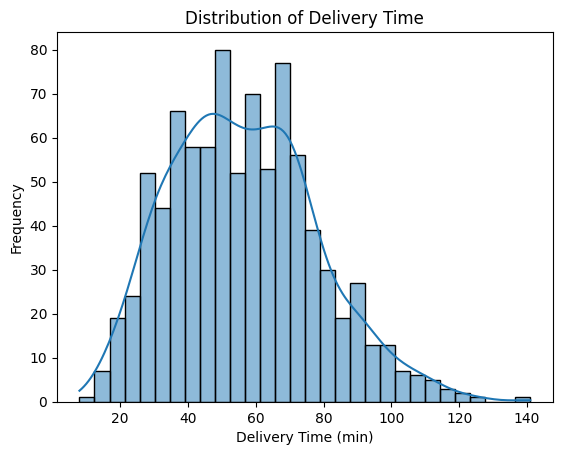

In [221]:
plt.figure()
sns.histplot(df["Delivery_Time_min"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

### Interpretation

The distribution of delivery time appears slightly right-skewed.

Most deliveries are concentrated between 40 and 80 minutes, with fewer extreme values on the higher end.

This suggests that while most deliveries are moderate in duration, some take significantly longer.




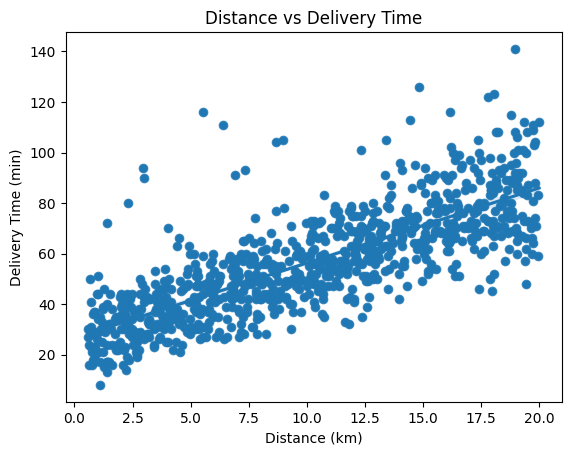

In [222]:
plt.figure()
sns.scatterplot(x=df["Distance_km"], y=df["Delivery_Time_min"])
sns.regplot(x=df["Distance_km"], y=df["Delivery_Time_min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

### Interpretation

There is a clear positive relationship between distance and delivery time.

As distance increases, delivery time also tends to increase, which indicates that distance is one of the most important predictors.




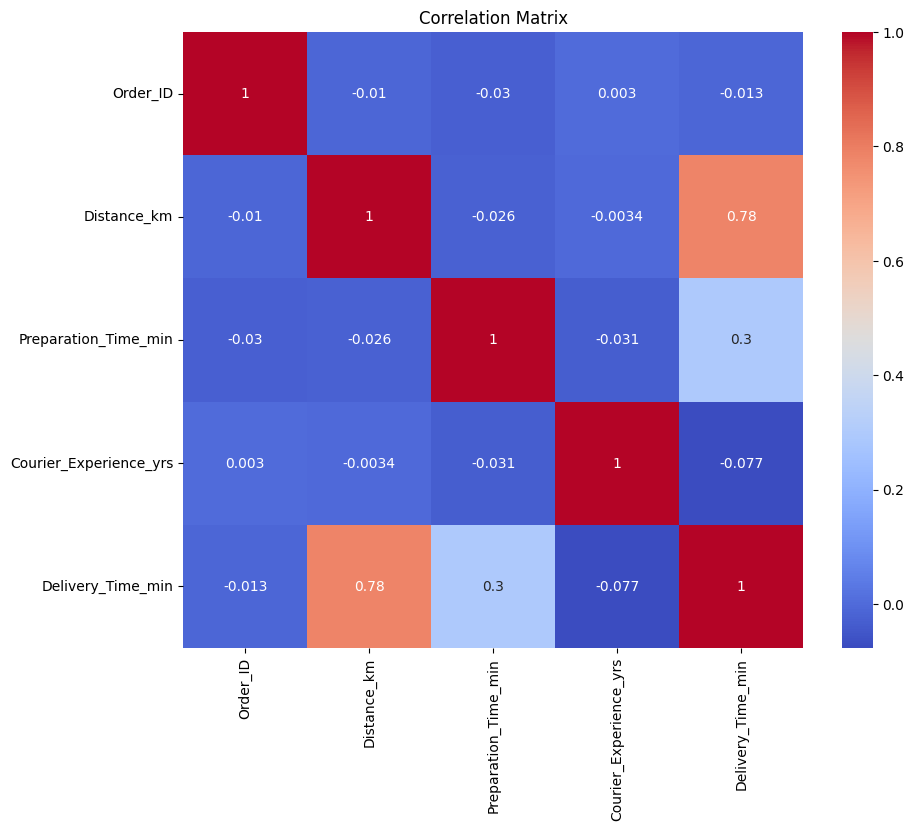

In [223]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Interpretation

The correlation matrix shows that:

- Distance_km has a strong positive correlation with delivery time (around 0.78), making it the most important numerical feature.
- Preparation_Time_min has a moderate correlation (~0.3), indicating some influence.
- Courier_Experience_yrs has a weak correlation, suggesting a limited impact.

This confirms that distance is the dominant factor in predicting delivery time.




## Train-test split

We split the dataset into training and testing sets.

This is essential to evaluate model performance on unseen data.

The training set is used to learn patterns, while the test set is used to measure how well the model generalizes.

We use random_state=42 to ensure reproducibility.

In [224]:
X = df.drop(["Order_ID", "Delivery_Time_min"], axis=1)
y = df["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing strategy

Before training the model, we need to transform the data into a suitable format.

We use a Pipeline with a ColumnTransformer to ensure a clean and reproducible workflow.

- Numerical features are imputed using the median to handle missing values robustly
- Categorical features are imputed using the most frequent value and encoded using OneHotEncoder

This approach ensures that:
- preprocessing is applied consistently
- no data leakage occurs (transformations are learned only on training data)
- the pipeline can be reused in production

In [225]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [226]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Model training

We train three regression models:

- Linear Regression: simple and interpretable baseline
- Random Forest: ensemble model capturing non-linear relationships
- Gradient Boosting: sequential model that improves predictions iteratively

Comparing multiple models helps identify which one best fits the data.

In [227]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}
results = {}

## Model Evaluation

We evaluate models using both cross-validation and a test set.

Cross-validation (5 folds) provides a more reliable estimate by reducing dependence on a single data split.

After that, models are tested on unseen data to measure real performance.

### Metrics
- **MAE**: average error (in minutes)
- **RMSE**: penalizes large errors
- **R²**: explains how well the model fits the data

Comparing cross-validation and test results helps detect overfitting and ensures model reliability.

In [228]:
for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error"
    )
    
    cv_mae = -cv_scores.mean()
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    test_mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = test_mae
    
    print(f"{name}:")
    print("CV MAE:", cv_mae)
    print("Test MAE:", test_mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print("-" * 30)

Linear:
CV MAE: 6.376511804378677
Test MAE: 5.319617041145188
RMSE: 8.273316732781119
R²: 0.8325314582304301
------------------------------
RandomForest:
CV MAE: 7.874504108885463
Test MAE: 6.9172316384180785
RMSE: 9.820511999493885
R²: 0.7640379297082015
------------------------------
GradientBoosting:
CV MAE: 7.1170436722908095
Test MAE: 6.561542960803049
RMSE: 9.288945141054876
R²: 0.7888910077005091
------------------------------


### Interpretation

Cross-validation and test results are relatively close, which suggests that the models generalize well and are not overfitting.

## Model comparison

Linear Regression achieved the lowest MAE compared to Random Forest and Gradient Boosting.

This suggests that the relationship between features and the target variable is mostly linear after preprocessing.

More complex models did not significantly improve performance, which indicates that the dataset does not require highly non-linear models.




## Residual analysis

Residuals represent the difference between actual and predicted values.

Analyzing residuals helps detect:
- bias in the model
- non-linear patterns
- heteroscedasticity

A good model should have residuals centered around zero with no clear pattern.

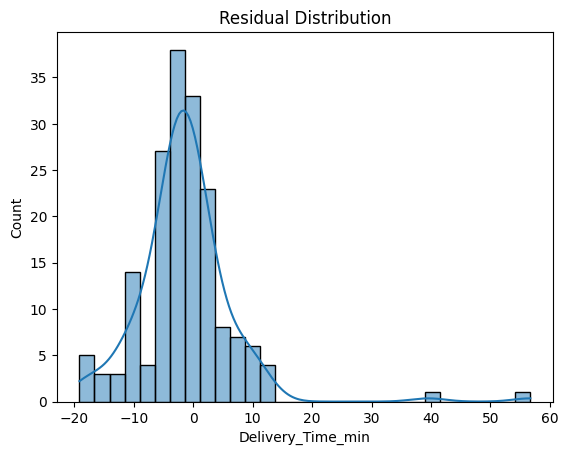

In [229]:
best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

best_pipeline.fit(X_train, y_train)
preds = best_pipeline.predict(X_test)

residuals = y_test - preds

plt.figure()
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.show()

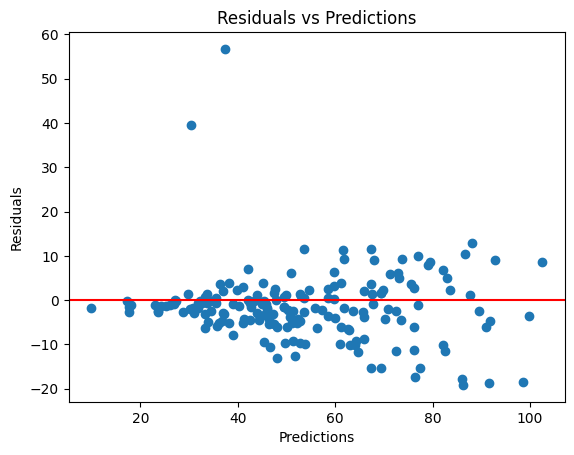

In [230]:
plt.figure()
plt.scatter(preds, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

### Interpretation

The residual distribution is centered around zero, which indicates that the model does not have a strong bias.

Most residuals are small, although a few larger errors are present, corresponding to difficult cases.

The scatter plot of residuals vs predictions does not show a strong pattern, suggesting that the model captures the main relationships in the data.

However, the spread of residuals slightly increases for higher predictions, which may indicate mild heteroscedasticity.

### Limitations

Although the model performs well, some prediction errors remain, especially for extreme delivery times.

This suggests that additional features or more advanced models could further improve performance.

In [231]:
LinearRegression().get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

## Hyperparameter tuning

We use GridSearchCV to optimize model parameters.

GridSearch tests multiple combinations of hyperparameters using cross-validation.

This helps:
- improve model performance
- avoid overfitting
- select the best configuration automatically

In this case, tuning Linear Regression has limited impact because the model has few hyperparameters.

In [232]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

param_grid = {
    "model__copy_X": [True, False],
    "model__fit_intercept": [True, False],
    "model__positive": [True, False]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

{'model__copy_X': True, 'model__fit_intercept': True, 'model__positive': False}


In [233]:
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print("Final MAE:", mae)

Final MAE: 5.319617041145188


## Hyperparameter tuning results

The hyperparameter tuning did not significantly improve performance.

This is expected because Linear Regression has very limited hyperparameters, and their impact on predictions is minimal.




In [234]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAE'])
results_df.sort_values(by="MAE")

,MAE
Linear,5.319617
GradientBoosting,6.561543
RandomForest,6.917232


## Feature importance

For Linear Regression, feature importance is derived from model coefficients.

Positive coefficients increase predicted delivery time, while negative ones decrease it.

This allows us to understand how each feature influences the prediction.

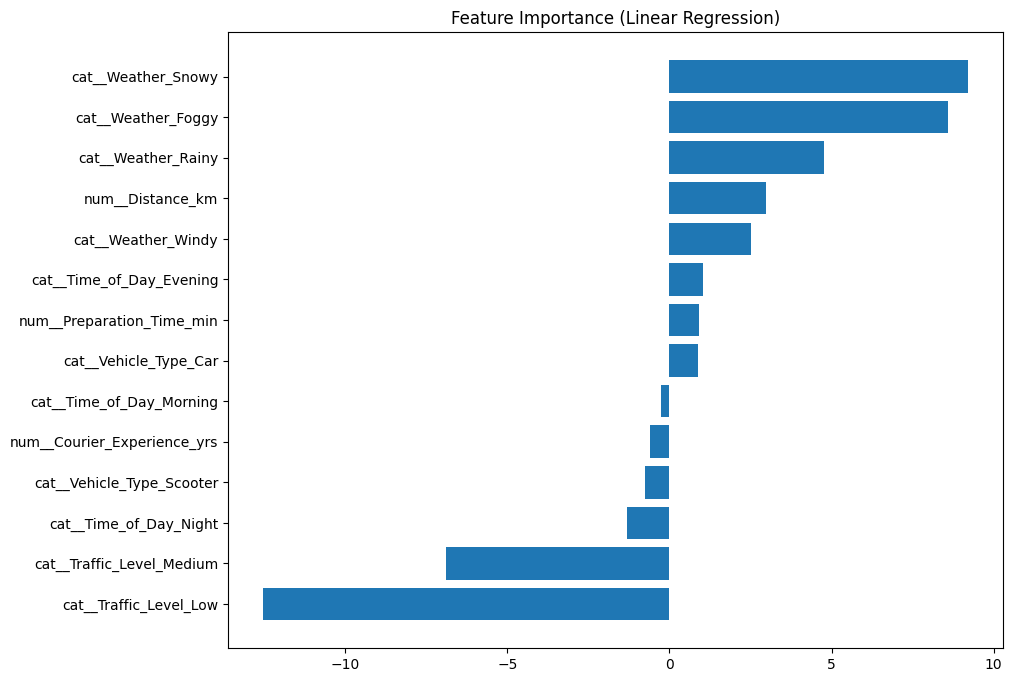

In [235]:
importances = best_model.named_steps["model"].coef_
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": importances
}).sort_values(by="coef")

plt.figure(figsize=(10,8))
plt.barh(coef_df["feature"], coef_df["coef"])
plt.title("Feature Importance (Linear Regression)")
plt.show()

## Feature importance interpretation

The most important features are:

- Weather conditions (especially snowy and foggy)
- Distance
- Traffic levels

Negative coefficients (e.g., low traffic) reduce delivery time, while positive ones increase it.

This confirms that both environmental conditions and distance play a major role.




In [236]:
joblib.dump(best_model, "models/model_pipeline.joblib")

['models/model_pipeline.joblib']

In [237]:
print(X.columns.tolist())

['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']


## Final conclusion

This project demonstrates a complete machine learning workflow, from data exploration to model deployment.

The results show that:
- distance is the most influential feature
- traffic and weather also play a significant role
- a simple linear model is sufficient for this dataset

Using a pipeline ensures a robust and reproducible approach.